In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/creditcard.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [2]:
print("Data types:\n", df.dtypes)

Data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [3]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [4]:
print("Class distribution:\n", df['Class'].value_counts())
print("\nPercentage:\n", df['Class'].value_counts(normalize=True) * 100)

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [6]:
print("Basic statistics:\n")
print(df[['Amount', 'Time']].describe())

#.describe()
# THIS is what did all the calculations!
# it automatically calculates:
# count  → how many rows
# mean   → average
# std    → standard deviation
# min    → smallest value
# 25%    → 25th percentile
# 50%    → median (middle value)
# 75%    → 75th percentile
# max    → largest value

#df[['Amount', 'Time']]  →  "which columns"
#.describe()             →  "calculate everything for me"

Basic statistics:

              Amount           Time
count  284807.000000  284807.000000
mean       88.349619   94813.859575
std       250.120109   47488.145955
min         0.000000       0.000000
25%         5.600000   54201.500000
50%        22.000000   84692.000000
75%        77.165000  139320.500000
max     25691.160000  172792.000000


In [7]:
print("Fraud transactions - Amount stats:")
print(df[df['Class']==1]['Amount'].describe())

print("\nLegitimate transactions - Amount stats:")
print(df[df['Class']==0]['Amount'].describe())

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Legitimate transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


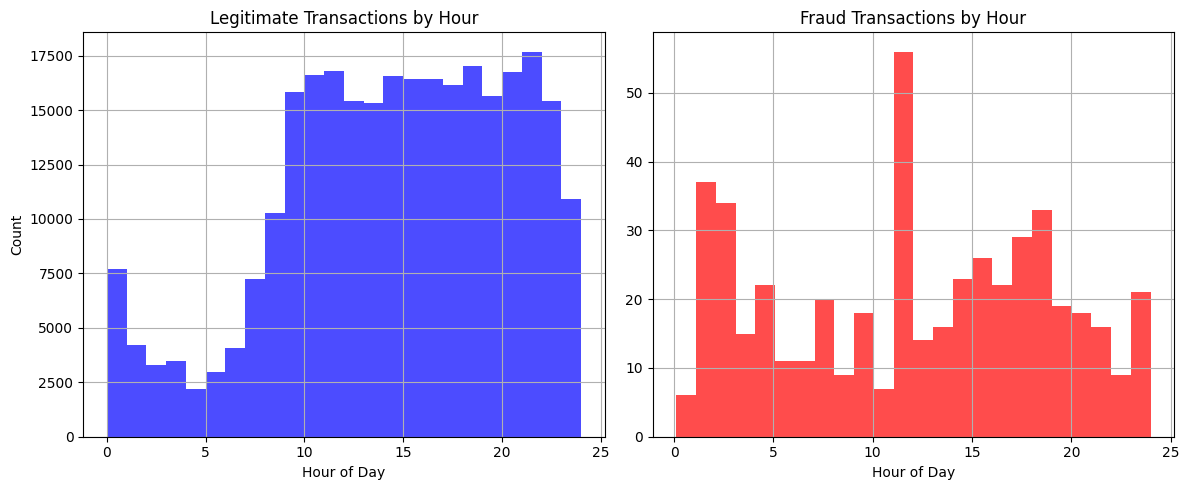

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create hour of day feature
df['Hour'] = (df['Time'] / 3600) % 24

# Plot fraud vs legitimate by hour
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df[df['Class']==0]['Hour'].hist(bins=24, color='blue', alpha=0.7)
plt.title('Legitimate Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.subplot(1,2,2)
df[df['Class']==1]['Hour'].hist(bins=24, color='red', alpha=0.7)
plt.title('Fraud Transactions by Hour')
plt.xlabel('Hour of Day')

plt.tight_layout()
plt.savefig('../visualizations/transactions_by_hour.png')
plt.show()

In [9]:
#Legitimate transactions (Blue):
#========================================================
# Very low activity between 2AM - 6AM — people sleeping
# Picks up from 8AM onwards — work hours
# Peaks between 9AM - 11PM — active business hours
# Makes total sense for normal spending behavior 

# Fraud transactions (Red):
#=======================================================
# Happens ALL hours — even 2AM, 3AM, 4AM
# Biggest spike around 11AM-12PM
# No clear pattern — scattered throughout the day
# Fraud doesn't sleep! 


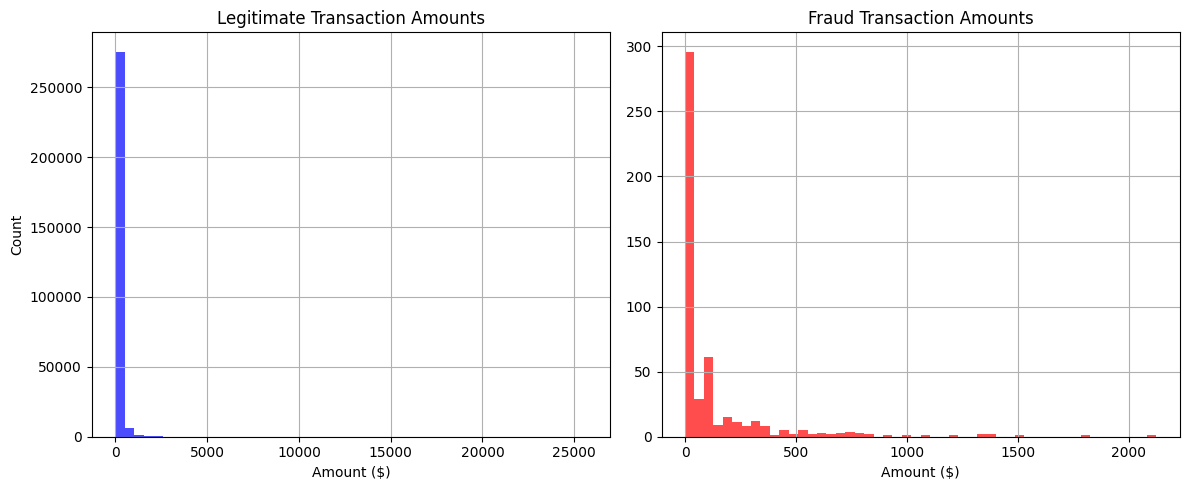

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df[df['Class']==0]['Amount'].hist(bins=50, color='blue', alpha=0.7)
plt.title('Legitimate Transaction Amounts')
plt.xlabel('Amount ($)')
plt.ylabel('Count')

plt.subplot(1,2,2)
df[df['Class']==1]['Amount'].hist(bins=50, color='red', alpha=0.7)
plt.title('Fraud Transaction Amounts')
plt.xlabel('Amount ($)')

plt.tight_layout()
plt.savefig('../visualizations/amount_distribution.png')
plt.show()

In [ ]:
# What this tells us:
# Legitimate transactions (Blue):

# Massive spike at very low amounts — most transactions under $500
# Long tail going all the way to $25,691
# Most people make small everyday purchases 

# Fraud transactions (Red):

# Also clustered at low amounts — under $500
# But tail stops at $2,125 — no very large fraud transactions
# Confirms our earlier finding — fraudsters avoid very large amounts to stay undetected

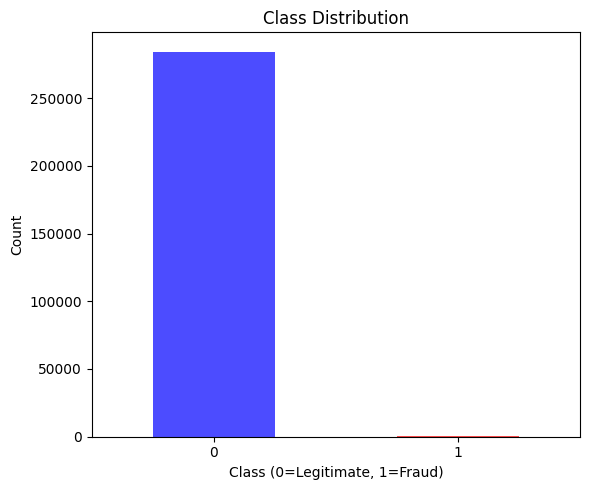


Legitimate: 284,315
Fraud: 492
Fraud percentage: 0.17%


In [11]:
plt.figure(figsize=(6,5))
df['Class'].value_counts().plot(kind='bar', 
                                color=['blue','red'],
                                alpha=0.7)
plt.title('Class Distribution')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../visualizations/class_distribution.png')
plt.show()

print(f"\nLegitimate: {df['Class'].value_counts()[0]:,}")
print(f"Fraud: {df['Class'].value_counts()[1]:,}")
print(f"Fraud percentage: {df['Class'].value_counts()[1]/len(df)*100:.2f}%")

In [16]:
correlation = df.corr()['Class'].sort_values(ascending=False)
correlation = correlation.drop('Class')

top10 = pd.concat([correlation.head(5), correlation.tail(5)])
df_display = pd.DataFrame({
    'Feature': top10.index,
    'Correlation': top10.values.round(3),
    'Relationship': ['More fraud' if x > 0 
                     else 'Less fraud' for x in top10.values]
})
print(df_display.to_string(index=False))

Feature  Correlation Relationship
    V11        0.155   More fraud
     V4        0.133   More fraud
     V2        0.091   More fraud
    V21        0.040   More fraud
    V19        0.035   More fraud
    V16       -0.197   Less fraud
    V10       -0.217   Less fraud
    V12       -0.261   Less fraud
    V14       -0.303   Less fraud
    V17       -0.326   Less fraud


#MY UNDERSTANDING

#In the dataset:
# When V11 has HIGH numbers → transaction is usually FRAUD
# When V11 has LOW numbers  → transaction is usually LEGITIMATE
# In the dataset:
# When V17 has LOW numbers  → transaction is usually FRAUD
# When V17 has HIGH numbers → transaction is usually LEGITIMATE


# IDEAL
# Fraud transaction:
# V11(HIGH)  +  V17(LOW)  =  FRAUD 

# Legitimate transaction:
# V11(LOW)  +  V17(HIGH) =  LEGITIMATE 
#V11(HIGH) +  V17(HIGH) = other features are taken into consideration always, doesnt depend only on few features.

In [13]:
print("=" * 50)
print("EXPLORATION SUMMARY")
print("=" * 50)
print(f"Total transactions: {len(df):,}")
print(f"Total features: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Legitimate transactions: {df['Class'].value_counts()[0]:,}")
print(f"Fraud transactions: {df['Class'].value_counts()[1]:,}")
print(f"Fraud percentage: {df['Class'].value_counts()[1]/len(df)*100:.2f}%")
print(f"Average legitimate amount: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Average fraud amount: ${df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Most correlated feature: V17 (negative), V11 (positive)")
print("=" * 50)

EXPLORATION SUMMARY
Total transactions: 284,807
Total features: 32
Missing values: 0
Legitimate transactions: 284,315
Fraud transactions: 492
Fraud percentage: 0.17%
Average legitimate amount: $88.29
Average fraud amount: $122.21
Most correlated feature: V17 (negative), V11 (positive)


 #MY UNDERSTANDING
# Severe imbalance -> SMOTE +Class weihts
# Fraudsters avoid very large amounts to stay undetected
# Hour of day is useful feature
# No single feature is strong enough alone,Model needs ALL 30 features together